# **Algoritma *Support Vector Machine* (SVM)**

## Import Library

In [1]:
# --- LIBRARY UTAMA UNTUK DATA DAN NUMERIK ---
import pandas as pd  # Manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # Komputasi numerik
np.random.seed(0)  # Seed untuk reproducibility
import random  # Untuk randomisasi

# --- VISUALISASI ---
import matplotlib.pyplot as plt  # Visualisasi data
import seaborn as sns  # Visualisasi statistik
from wordcloud import WordCloud  # Awan kata
from collections import Counter  # Hitung frekuensi kata

# --- PEMROSESAN TEKS DASAR ---
import re  # Ekspresi reguler
import string  # Tanda baca
import csv  # Membaca/menulis file CSV
import datetime as dt  # Tanggal dan waktu

# --- NLP (Natural Language Processing) ---
import nltk  # Toolkit NLP
from nltk.tokenize import word_tokenize  # Tokenisasi
from nltk.corpus import stopwords  # Stopword bahasa Inggris
from textblob import TextBlob  # Sentiment Analysis bahasa Inggris

# --- NLP Bahasa Indonesia ---
# Jalankan hanya jika belum install:
!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Stopword bahasa Indonesia

# --- WEB & STREAM ---
import requests  # Untuk ambil data dari web
from io import StringIO  # Untuk membaca file dari string

# --- MACHINE LEARNING & PREPROCESSING ---
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF vektor teks
from sklearn.model_selection import train_test_split, GridSearchCV  # Pembagian data & optimisasi
from sklearn.preprocessing import LabelEncoder  # Encoding label ke angka
from sklearn.naive_bayes import BernoulliNB  # Naive Bayes Classifier
from sklearn.linear_model import LogisticRegression  # Regresi logistik
from sklearn.metrics import accuracy_score, precision_score  # Evaluasi performa

# --- DEEP LEARNING: TENSORFLOW / KERAS ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense,
    LSTM, SimpleRNN, Bidirectional, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


In [2]:
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Loading Dataset

In [3]:
import pandas as pd

# URL yang lebih standar untuk file raw di GitHub
url = "https://raw.githubusercontent.com/lailarizzah/Analisis-Sentimen-Malaka-Project/refs/heads/main/komentar_yt.csv"

print("Mencoba memuat dataset langsung dari URL...")

try:
    komentar_df = pd.read_csv(url, on_bad_lines='skip', encoding='utf-8')

    print("Dataset berhasil dimuat!")

    # Menampilkan informasi DataFrame
    komentar_df.info()

    # Menampilkan beberapa baris pertama
    print("\nContoh data:")
    print(komentar_df.head())

except Exception as e:
    print(f"Terjadi error saat memuat data: {e}")

Mencoba memuat dataset langsung dari URL...
Dataset berhasil dimuat!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3428 entries, 0 to 3427
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  3428 non-null   object
dtypes: object(1)
memory usage: 26.9+ KB

Contoh data:
                                             comment
0  Tonton sampai habis &amp; kasih pendapat kalia...
1                          Gibrann gibrann ampun dah
2                        DURASI KURANG SAAATTTGGGHHH
3  Audionya tolong diperhatiin, pas ngobrol suara...
4  Suaranya terlalu kecil, tidak terlalu kedengar...


### Random Set
Berfungsi supaya hasil eksperimen lebih konsisten ketika dijalankan ulang.

In [4]:
# Step 2: Set seed

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Kalau pakai TensorFlow/Keras:
tf.random.set_seed(SEED)

## Data Preparation

In [5]:
import pandas as pd

# =================================================================
# DATA PREPARATION (PEMBERSIHAN DATA AWAL)
# =================================================================
print("--- Memulai Data Preparation ---")

# 1. Menangani Data Duplikat & Kosong (Kode Anda)
print("\n1. Membersihkan data duplikat dan kosong...")
print(f"Jumlah baris awal: {len(komentar_df)}")

# Hapus baris yang kolom 'comment'-nya kosong
komentar_df.dropna(subset=['comment'], inplace=True)
# Hapus baris yang isi komentarnya sama persis
komentar_df.drop_duplicates(subset=['comment'], inplace=True)

print(f"Jumlah baris setelah dibersihkan (duplikat & kosong): {len(komentar_df)}")

# -----------------------------------------------------------------
# 2. Menangani Komentar Spam
# -----------------------------------------------------------------
print("\n2. Membersihkan komentar spam (judi online)...")

# Daftar kata kunci spam yang sudah kita perbarui
spam_keywords = [
    'slot', 'gacor', 'rtp', 'maxwin', 'deposit', 'wd', 'hoki',
    'scatter', 'jp', 'bonus', 'link', 'daftar', 'login', 'agen', 'situs',
    'probet', 'jptogel', 'mandalika', 'visi4d', 'dewadora', 'aero88',
    'dora77', 'jepe', 'jackpot'
]
spam_pattern = '|'.join(spam_keywords)

# Catat jumlah sebelum difilter
jumlah_sebelum_spam = len(komentar_df)

# Filter data spam berdasarkan kolom 'comment'
komentar_df = komentar_df[~komentar_df['comment'].str.contains(spam_pattern, case=False, na=False)]

jumlah_setelah_spam = len(komentar_df)
jumlah_spam_dibuang = jumlah_sebelum_spam - jumlah_setelah_spam

print(f"✅ Sebanyak {jumlah_spam_dibuang} baris komentar spam berhasil dibuang.")
print(f"Jumlah baris final setelah semua pembersihan: {jumlah_setelah_spam}")

# -----------------------------------------------------------------
# 3. Cek Final
# -----------------------------------------------------------------
print("\n--- ✅ Data Preparation Selesai ---")
print("Informasi data final sebelum di-split:")
komentar_df.info()

--- Memulai Data Preparation ---

1. Membersihkan data duplikat dan kosong...
Jumlah baris awal: 3428
Jumlah baris setelah dibersihkan (duplikat & kosong): 3384

2. Membersihkan komentar spam (judi online)...
✅ Sebanyak 54 baris komentar spam berhasil dibuang.
Jumlah baris final setelah semua pembersihan: 3330

--- ✅ Data Preparation Selesai ---
Informasi data final sebelum di-split:
<class 'pandas.core.frame.DataFrame'>
Index: 3330 entries, 0 to 3427
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  3330 non-null   object
dtypes: object(1)
memory usage: 52.0+ KB


## Preprocessing

### Data Cleaning

Proses ini bertujuan untuk membersihkan teks dari HTML, URL, emoji, angka, dan simbol.

In [6]:
import pandas as pd
import re

# =================================================================
# 1. DEFINISIKAN FUNGSI CLEANING
# =================================================================
# Pastikan fungsi ini sudah ada di script Anda
def cleaning(text):
    """
    Fungsi untuk membersihkan teks dari HTML, URL, emoji, angka, dan simbol.
    """
    # Mengatasi jika input bukan string (misal: data kosong/None)
    if not isinstance(text, str):
        return ""

    # Hapus tag HTML
    text = re.sub(r'<.*?>', '', text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus Emoji
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)
    # Hapus Angka
    text = re.sub(r'\d+', '', text)
    # Hapus Simbol dan Tanda Baca
    text = re.sub(r'[^\w\s]', '', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =================================================================
# 2. TERAPKAN FUNGSI PADA DATAFRAME
# =================================================================
komentar_df['cleaning'] = komentar_df['comment'].apply(cleaning)

# =================================================================
# 3. TAMPILKAN HASIL UNTUK VERIFIKASI
# =================================================================
print("Hasil proses cleaning pada DataFrame:")
komentar_df[['comment', 'cleaning']].head(500)

Hasil proses cleaning pada DataFrame:


,comment,cleaning
0,Tonton sampai habis &amp; kasih pendapat kalia...,Tonton sampai habis amp kasih pendapat kalian ...
1,Gibrann gibrann ampun dah,Gibrann gibrann ampun dah
2,DURASI KURANG SAAATTTGGGHHH,DURASI KURANG SAAATTTGGGHHH
3,"Audionya tolong diperhatiin, pas ngobrol suara...",Audionya tolong diperhatiin pas ngobrol suara ...
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",Suaranya terlalu kecil tidak terlalu kedengara...
...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",DOKTER SPESIALIS YG PROMOIN SUPLEMEN GUE TAHU ...
505,Audio buruk,Audio buruk
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",Thx u Malaka n dr Tirta akhirnya ada yg menyua...


### Case Folding

Case folding adalah proses mengubah semua huruf dalam teks menjadi seragam, biasanya menjadi huruf kecil (lowercase).

In [7]:
def case_folding(text):
    return text.lower()

print("\nMemulai proses case folding...")
# Mengambil data dari kolom 'cleaned'
komentar_df['case folding'] = komentar_df['cleaning'].apply(case_folding)

print("\n--- Hasil setelah Case Folding ---")
# Menampilkan kolom hasil cleaning dan case folding
komentar_df[['comment', 'case folding']].head(500)


Memulai proses case folding...

--- Hasil setelah Case Folding ---


,comment,case folding
0,Tonton sampai habis &amp; kasih pendapat kalia...,tonton sampai habis amp kasih pendapat kalian ...
1,Gibrann gibrann ampun dah,gibrann gibrann ampun dah
2,DURASI KURANG SAAATTTGGGHHH,durasi kurang saaatttggghhh
3,"Audionya tolong diperhatiin, pas ngobrol suara...",audionya tolong diperhatiin pas ngobrol suara ...
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",suaranya terlalu kecil tidak terlalu kedengara...
...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",dokter spesialis yg promoin suplemen gue tahu ...
505,Audio buruk,audio buruk
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",thx u malaka n dr tirta akhirnya ada yg menyua...


### Tokenization

Tokenisasi adalah proses memecah sebuah kalimat menjadi potongan-potongan kecil yang disebut "token". Ini adalah langkah fundamental dalam Natural Language Processing (NLP) karena mengubah data dari format kalimat (string) yang sulit diolah menjadi format daftar kata (list) yang mudah dianalisis oleh mesin.

In [8]:
from nltk.tokenize import word_tokenize
# =================================================================
# 1. TOKENIZING
# =================================================================
print("Memulai proses tokenizing...")

# Menerapkan fungsi word_tokenize pada setiap baris di kolom 'komentar_bersih'
# Kita akan membuat kolom baru bernama 'komentar_tokens' untuk menyimpan hasilnya
komentar_df['tokenize'] = komentar_df['case folding'].apply(word_tokenize)

# =================================================================
# 2. TAMPILKAN HASIL UNTUK VERIFIKASI
# =================================================================
print("\nHasil setelah tokenizing (5 baris pertama):")
# Menampilkan kolom teks bersih dan kolom hasil tokenizing
komentar_df[['comment', 'cleaning','case folding', 'tokenize']].head(500)

Memulai proses tokenizing...

Hasil setelah tokenizing (5 baris pertama):


,comment,cleaning,case folding,tokenize
0,Tonton sampai habis &amp; kasih pendapat kalia...,Tonton sampai habis amp kasih pendapat kalian ...,tonton sampai habis amp kasih pendapat kalian ...,"[tonton, sampai, habis, amp, kasih, pendapat, ..."
1,Gibrann gibrann ampun dah,Gibrann gibrann ampun dah,gibrann gibrann ampun dah,"[gibrann, gibrann, ampun, dah]"
2,DURASI KURANG SAAATTTGGGHHH,DURASI KURANG SAAATTTGGGHHH,durasi kurang saaatttggghhh,"[durasi, kurang, saaatttggghhh]"
3,"Audionya tolong diperhatiin, pas ngobrol suara...",Audionya tolong diperhatiin pas ngobrol suara ...,audionya tolong diperhatiin pas ngobrol suara ...,"[audionya, tolong, diperhatiin, pas, ngobrol, ..."
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",Suaranya terlalu kecil tidak terlalu kedengara...,suaranya terlalu kecil tidak terlalu kedengara...,"[suaranya, terlalu, kecil, tidak, terlalu, ked..."
...,...,...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok,awal nanya sibuk ap dok,"[awal, nanya, sibuk, ap, dok]"
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",DOKTER SPESIALIS YG PROMOIN SUPLEMEN GUE TAHU ...,dokter spesialis yg promoin suplemen gue tahu ...,"[dokter, spesialis, yg, promoin, suplemen, gue..."
505,Audio buruk,Audio buruk,audio buruk,"[audio, buruk]"
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",Thx u Malaka n dr Tirta akhirnya ada yg menyua...,thx u malaka n dr tirta akhirnya ada yg menyua...,"[thx, u, malaka, n, dr, tirta, akhirnya, ada, ..."


### Normalization

Normalisasi bertujuan untuk mengubah kata-kata yang sebelumnya menggunakan singkatan, mengandung typo, atau kata tidak baku menjadi baku.

In [9]:
import pandas as pd

url = "https://raw.githubusercontent.com/lailarizzah/Analisis-Sentimen-Malaka-Project/refs/heads/main/kamus_slang.csv"

slang_df = pd.read_csv(url)
slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))

# =================================================================
# 1. BUAT FUNGSI NORMALISASI
# =================================================================
def normalize_text(tokens):
    return [slang_dict.get(word, word) for word in tokens]

# =================================================================
# 2. TERAPKAN FUNGSI KE DATAFRAME `komentar_df`
# =================================================================
print("Memulai proses normalisasi kata...")

# Terapkan fungsi ke kolom 'komentar_bersih'
komentar_df['normalize_text'] = komentar_df['tokenize'].apply(normalize_text)

# =================================================================
# 3. TAMPILKAN HASIL UNTUK VERIFIKASI
# =================================================================
print("\nHasil setelah normalisasi kata (5 baris pertama):")
komentar_df[['comment', 'cleaning','case folding', 'tokenize', 'normalize_text']].head(500)

Memulai proses normalisasi kata...

Hasil setelah normalisasi kata (5 baris pertama):


,comment,cleaning,case folding,tokenize,normalize_text
0,Tonton sampai habis &amp; kasih pendapat kalia...,Tonton sampai habis amp kasih pendapat kalian ...,tonton sampai habis amp kasih pendapat kalian ...,"[tonton, sampai, habis, amp, kasih, pendapat, ...","[tonton, sampai, habis, amp, kasih, pendapat, ..."
1,Gibrann gibrann ampun dah,Gibrann gibrann ampun dah,gibrann gibrann ampun dah,"[gibrann, gibrann, ampun, dah]","[gibrann, gibrann, ampun, deh]"
2,DURASI KURANG SAAATTTGGGHHH,DURASI KURANG SAAATTTGGGHHH,durasi kurang saaatttggghhh,"[durasi, kurang, saaatttggghhh]","[durasi, kurang, saaatttggghhh]"
3,"Audionya tolong diperhatiin, pas ngobrol suara...",Audionya tolong diperhatiin pas ngobrol suara ...,audionya tolong diperhatiin pas ngobrol suara ...,"[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audionya, tolong, diperhatiin, pas, ngobrol, ..."
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",Suaranya terlalu kecil tidak terlalu kedengara...,suaranya terlalu kecil tidak terlalu kedengara...,"[suaranya, terlalu, kecil, tidak, terlalu, ked...","[suaranya, terlalu, kecil, tidak, terlalu, ked..."
...,...,...,...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok,awal nanya sibuk ap dok,"[awal, nanya, sibuk, ap, dok]","[awal, bertanya, sibuk, apa, dok]"
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",DOKTER SPESIALIS YG PROMOIN SUPLEMEN GUE TAHU ...,dokter spesialis yg promoin suplemen gue tahu ...,"[dokter, spesialis, yg, promoin, suplemen, gue...","[dokter, spesialis, yang, promoin, suplemen, s..."
505,Audio buruk,Audio buruk,audio buruk,"[audio, buruk]","[audio, buruk]"
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",Thx u Malaka n dr Tirta akhirnya ada yg menyua...,thx u malaka n dr tirta akhirnya ada yg menyua...,"[thx, u, malaka, n, dr, tirta, akhirnya, ada, ...","[terima kasih, kamu, malaka, dan, dr, tirta, a..."


### Stopword Removal

Stopword removal merupakan proses penghapusan kata-kata yang memiliki frekuensi kemunculan tinggi tetapi kurang merepresentasikan isi dokumen, seperti kata hubung, kata depan, dan kata ganti.

In [10]:
from nltk.corpus import stopwords

def filtering(tokens, stopwords_set):
    if not isinstance(tokens, list):
        return []

    return [
        word for word in tokens
        if word not in stopwords_set
    ]

print("\nMemulai proses filtering (stopword removal)...")

# --- Membuat Daftar Stopwords ---
# Menggunakan set untuk pencarian yang lebih cepat
list_stopwords = set(stopwords.words('indonesian'))
list_stopwords.update(set(stopwords.words('english')))
# Perbaikan: Menambahkan tanda kutip tunggal penutup untuk 'yg'
list_stopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah",'yg','yg','nya','aja','sih','kak'])
print("✅ Daftar stopwords siap.")

# Mengambil data dari kolom 'tokenized'
komentar_df['stopwords_removed'] = \
    komentar_df['normalize_text'].apply(
        lambda x: filtering(x, list_stopwords)
)

print("\n--- Hasil setelah Filtering Stopwords ---")
# Menampilkan kolom hasil tokenizing dan filtering
komentar_df[['comment', 'cleaning','case folding', 'tokenize', 'normalize_text', 'stopwords_removed']].head(500)


Memulai proses filtering (stopword removal)...
✅ Daftar stopwords siap.

--- Hasil setelah Filtering Stopwords ---


,comment,cleaning,case folding,tokenize,normalize_text,stopwords_removed
0,Tonton sampai habis &amp; kasih pendapat kalia...,Tonton sampai habis amp kasih pendapat kalian ...,tonton sampai habis amp kasih pendapat kalian ...,"[tonton, sampai, habis, amp, kasih, pendapat, ...","[tonton, sampai, habis, amp, kasih, pendapat, ...","[tonton, habis, amp, kasih, pendapat, kolom, k..."
1,Gibrann gibrann ampun dah,Gibrann gibrann ampun dah,gibrann gibrann ampun dah,"[gibrann, gibrann, ampun, dah]","[gibrann, gibrann, ampun, deh]","[gibrann, gibrann, ampun, deh]"
2,DURASI KURANG SAAATTTGGGHHH,DURASI KURANG SAAATTTGGGHHH,durasi kurang saaatttggghhh,"[durasi, kurang, saaatttggghhh]","[durasi, kurang, saaatttggghhh]","[durasi, saaatttggghhh]"
3,"Audionya tolong diperhatiin, pas ngobrol suara...",Audionya tolong diperhatiin pas ngobrol suara ...,audionya tolong diperhatiin pas ngobrol suara ...,"[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audionya, tolong, diperhatiin, pas, ngobrol, ..."
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",Suaranya terlalu kecil tidak terlalu kedengara...,suaranya terlalu kecil tidak terlalu kedengara...,"[suaranya, terlalu, kecil, tidak, terlalu, ked...","[suaranya, terlalu, kecil, tidak, terlalu, ked...","[suaranya, kedengaran, pakai, earphone]"
...,...,...,...,...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok,awal nanya sibuk ap dok,"[awal, nanya, sibuk, ap, dok]","[awal, bertanya, sibuk, apa, dok]","[sibuk, dok]"
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",DOKTER SPESIALIS YG PROMOIN SUPLEMEN GUE TAHU ...,dokter spesialis yg promoin suplemen gue tahu ...,"[dokter, spesialis, yg, promoin, suplemen, gue...","[dokter, spesialis, yang, promoin, suplemen, s...","[dokter, spesialis, promoin, suplemen, banget,..."
505,Audio buruk,Audio buruk,audio buruk,"[audio, buruk]","[audio, buruk]","[audio, buruk]"
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",Thx u Malaka n dr Tirta akhirnya ada yg menyua...,thx u malaka n dr tirta akhirnya ada yg menyua...,"[thx, u, malaka, n, dr, tirta, akhirnya, ada, ...","[terima kasih, kamu, malaka, dan, dr, tirta, a...","[terima kasih, malaka, dr, tirta, menyuarakan,..."


### Stemming

In [11]:
# ================================================================
# 1. IMPORT LIBRARY
# ================================================================
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

# Aktifkan progress bar untuk pandas
tqdm.pandas()

# ================================================================
# 2. MEMBUAT OBJECT STEMMER
# ================================================================
print("Mempersiapkan stemmer Sastrawi...")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("✅ Stemmer siap digunakan.")

# ================================================================
# 3. FUNGSI STEMMING
# ================================================================
def stemming(tokens):
    """
    Mengubah kata menjadi bentuk dasar (stemming)

    Input  : list token
    Output : list token hasil stemming
    """

    # Menghindari error jika bukan list
    if not isinstance(tokens, list):
        return []

    stemmed_words = []

    # Proses stemming tiap kata
    for word in tokens:
        hasil = stemmer.stem(word)
        stemmed_words.append(hasil)

    return stemmed_words


# ================================================================
# 4. PROSES STEMMING DENGAN PROGRESS BAR
# ================================================================
print("\nMemulai proses stemming...")
print(f"Total data: {len(komentar_df)} komentar")

komentar_df['stemming'] = (
    komentar_df['stopwords_removed']
    .progress_apply(stemming)
)

print("✅ Proses stemming selesai.")

# ================================================================
# 5. MELIHAT HASIL PERUBAHAN
# ================================================================
print("\nContoh hasil stemming:")

komentar_df[
[
'comment',
'cleaning',
'case folding',
'tokenize',
'normalize_text',
'stopwords_removed',
'stemming'
]
].head()


# ================================================================
# 6. MEMBUAT FINAL TEXT (UNTUK TF-IDF / MODEL ML)
# ================================================================
print("\nMenggabungkan token menjadi kalimat akhir...")

komentar_df['final_text'] = komentar_df['stemming'].apply(
    lambda x: ' '.join(x)
)

print("✅ Final text siap digunakan.")

# ================================================================
# 7. CEK HASIL AKHIR
# ================================================================
komentar_df[['comment', 'cleaning','case folding', 'tokenize', 'normalize_text', 'stopwords_removed', 'stemming', 'final_text']].head(500)

Mempersiapkan stemmer Sastrawi...
✅ Stemmer siap digunakan.

Memulai proses stemming...
Total data: 3330 komentar


100%|██████████| 3330/3330 [13:43<00:00,  4.04it/s]

✅ Proses stemming selesai.

Contoh hasil stemming:

Menggabungkan token menjadi kalimat akhir...
✅ Final text siap digunakan.


,comment,cleaning,case folding,tokenize,normalize_text,stopwords_removed,stemming,final_text
0,Tonton sampai habis &amp; kasih pendapat kalia...,Tonton sampai habis amp kasih pendapat kalian ...,tonton sampai habis amp kasih pendapat kalian ...,"[tonton, sampai, habis, amp, kasih, pendapat, ...","[tonton, sampai, habis, amp, kasih, pendapat, ...","[tonton, habis, amp, kasih, pendapat, kolom, k...","[tonton, habis, amp, kasih, dapat, kolom, kome...",tonton habis amp kasih dapat kolom komentar
1,Gibrann gibrann ampun dah,Gibrann gibrann ampun dah,gibrann gibrann ampun dah,"[gibrann, gibrann, ampun, dah]","[gibrann, gibrann, ampun, deh]","[gibrann, gibrann, ampun, deh]","[gibrann, gibrann, ampun, deh]",gibrann gibrann ampun deh
2,DURASI KURANG SAAATTTGGGHHH,DURASI KURANG SAAATTTGGGHHH,durasi kurang saaatttggghhh,"[durasi, kurang, saaatttggghhh]","[durasi, kurang, saaatttggghhh]","[durasi, saaatttggghhh]","[durasi, saaatttggghhh]",durasi saaatttggghhh
3,"Audionya tolong diperhatiin, pas ngobrol suara...",Audionya tolong diperhatiin pas ngobrol suara ...,audionya tolong diperhatiin pas ngobrol suara ...,"[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audionya, tolong, diperhatiin, pas, ngobrol, ...","[audio, tolong, diperhatiin, pas, ngobrol, sua...",audio tolong diperhatiin pas ngobrol suara pas...
4,"Suaranya terlalu kecil, tidak terlalu kedengar...",Suaranya terlalu kecil tidak terlalu kedengara...,suaranya terlalu kecil tidak terlalu kedengara...,"[suaranya, terlalu, kecil, tidak, terlalu, ked...","[suaranya, terlalu, kecil, tidak, terlalu, ked...","[suaranya, kedengaran, pakai, earphone]","[suara, dengar, pakai, earphone]",suara dengar pakai earphone
...,...,...,...,...,...,...,...,...
503,awal nanya *sibuk ap dok*😅😂😂,awal nanya sibuk ap dok,awal nanya sibuk ap dok,"[awal, nanya, sibuk, ap, dok]","[awal, bertanya, sibuk, apa, dok]","[sibuk, dok]","[sibuk, dok]",sibuk dok
504,"DOKTER SPESIALIS YG PROMOIN SUPLEMEN, GUE TAHU...",DOKTER SPESIALIS YG PROMOIN SUPLEMEN GUE TAHU ...,dokter spesialis yg promoin suplemen gue tahu ...,"[dokter, spesialis, yg, promoin, suplemen, gue...","[dokter, spesialis, yang, promoin, suplemen, s...","[dokter, spesialis, promoin, suplemen, banget,...","[dokter, spesialis, promoin, suplemen, banget,...",dokter spesialis promoin suplemen banget follo...
505,Audio buruk,Audio buruk,audio buruk,"[audio, buruk]","[audio, buruk]","[audio, buruk]","[audio, buruk]",audio buruk
506,"Thx u Malaka n dr Tirta, akhirnya ada yg menyu...",Thx u Malaka n dr Tirta akhirnya ada yg menyua...,thx u malaka n dr tirta akhirnya ada yg menyua...,"[thx, u, malaka, n, dr, tirta, akhirnya, ada, ...","[terima kasih, kamu, malaka, dan, dr, tirta, a...","[terima kasih, malaka, dr, tirta, menyuarakan,...","[terima kasih, malaka, dr, tirta, suara, resah]",terima kasih malaka dr tirta suara resah


setelah stemming outputnya adalah kalimat karena text.split() cuma bisa jalan kalau input = string.

## Labeling Dataset

Proses labeling menggunakan kamus lexicon InSet yang dibuat oleh Fajri Koto, data berasal dari Kaggle.

In [12]:
import pandas as pd
import requests # Needed for downloading lexicon

# --- START: Added code to define 'label' column in komentar_df ---
# Memuat Kamus Lexicon
print("Mengunduh kamus leksikon untuk labeling...")
try:
    positive_url = "https://raw.githubusercontent.com/fajri91/InSet/refs/heads/master/positive.tsv"
    negative_url = "https://raw.githubusercontent.com/fajri91/InSet/refs/heads/master/negative.tsv"

    # Menggunakan set untuk pencarian kata yang lebih cepat
    positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
    negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

    print("Kamus leksikon berhasil dimuat.")
except Exception as e:
    print(f"Gagal memuat leksikon: {e}")
    positive_lexicon = set()
    negative_lexicon = set()

# Fungsi Labeling
def determine_sentiment(text):
    # Memastikan input adalah string
    if not isinstance(text, str):
        return 0, "Netral"

    # Menghitung jumlah kata positif dan negatif
    positive_count = sum(1 for word in text.lower().split() if word in positive_lexicon)
    negative_count = sum(1 for word in text.lower().split() if word in negative_lexicon)

    # Menghitung skor sentimen
    sentiment_score = positive_count - negative_count

    # Menentukan label
    if sentiment_score > 0:
        sentiment = "Positif"
    elif sentiment_score < 0:
        sentiment = "Negatif"
    else:
        sentiment = "Netral"

    return sentiment_score, sentiment

print("\nMemulai pelabelan otomatis pada komentar_df menggunakan 'final_text'...")
# Terapkan fungsi ke kolom 'final_text' dari komentar_df
# Pastikan 'final_text' tidak memiliki nilai NaN sebelum pelabelan
komentar_df['final_text'] = komentar_df['final_text'].fillna('')
komentar_df[['Score', 'label']] = komentar_df['final_text'].apply(lambda x: pd.Series(determine_sentiment(x)))

print("\nDistribusi kelas sentimen:")
print(komentar_df['label'].value_counts())
print("\nContoh hasil pelabelan :")
komentar_df[['comment', 'final_text', 'Score', 'label']].head(500)

# Simpan ke CSV
komentar_df.to_excel("komentar_df.xlsx", index=False)

Mengunduh kamus leksikon untuk labeling...
Kamus leksikon berhasil dimuat.

Memulai pelabelan otomatis pada komentar_df menggunakan 'final_text'...

Distribusi kelas sentimen:
label
Netral     1381
Positif    1015
Negatif     934
Name: count, dtype: int64

Contoh hasil pelabelan :


## Data Split

In [13]:
from sklearn.model_selection import train_test_split

X_text = komentar_df['final_text']
y = komentar_df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data:")
print(f"Data Train: {len(X_train_text)}")
print(f"Data Test : {len(X_test_text)}")

Jumlah data:
Data Train: 2664
Data Test : 666


## Ekstraksi Fitur

In [14]:
import pandas as pd

X_text = komentar_df['final_text']
y = komentar_df['label']

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)

# Tampilkan hasil TF-IDF
feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=feature_names
)

tfidf_df.head(50)
tfidf_df.to_csv("tfidf_result.csv", index=False)

Train shape: (2664, 1061)
Test shape : (666, 1061)


## Hasil TF-IDF

In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/lailarizzah/Analisis-Sentimen-Malaka-Project/refs/heads/main/tfidf_result.csv"

tfidf_df = pd.read_csv(url)

tfidf_df.head()

# Ambil 60 data dengan skor TF-IDF tertinggi
# Hitung jumlah nilai non-zero tiap dokumen
non_zero_count = (tfidf_df > 0).sum(axis=1)

# A# Ambil data dokumen
selected_docs = tfidf_df.loc[non_zero_count]

# Transpose
tfidf_table = selected_docs.T

# Ubah index jadi kolom
tfidf_table.reset_index(inplace=True)
tfidf_table.rename(columns={'index': 'Term'}, inplace=True)

# Simpan ke CSV
tfidf_table.to_excel("tfidf_table.xlsx", index=False)

# Preview
tfidf_table.head(5)


,Term,7,8,0,3,0,5,22,11,5,...,5,8,2,8,26,1,4,1,11,9
0,abang,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,acara,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ada,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,adik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,adil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Heatmap TF-IDF

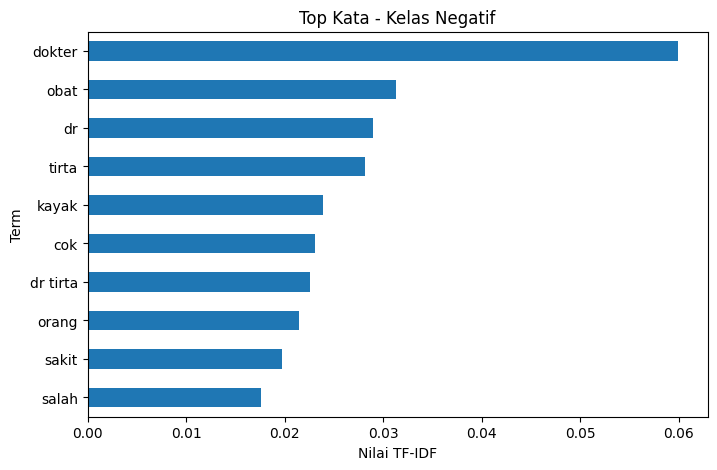

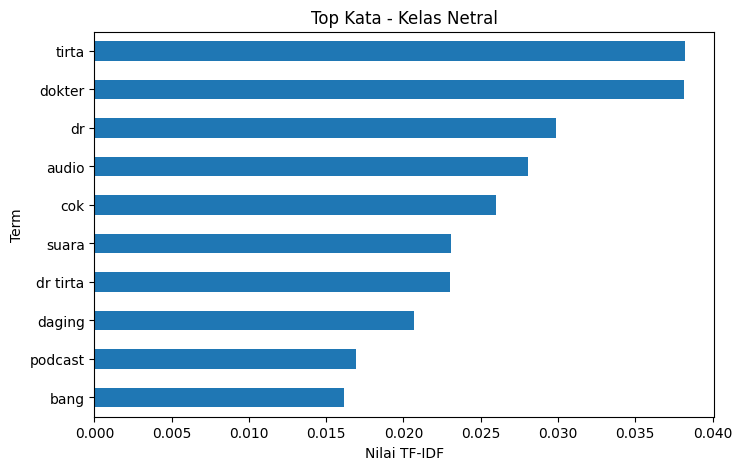

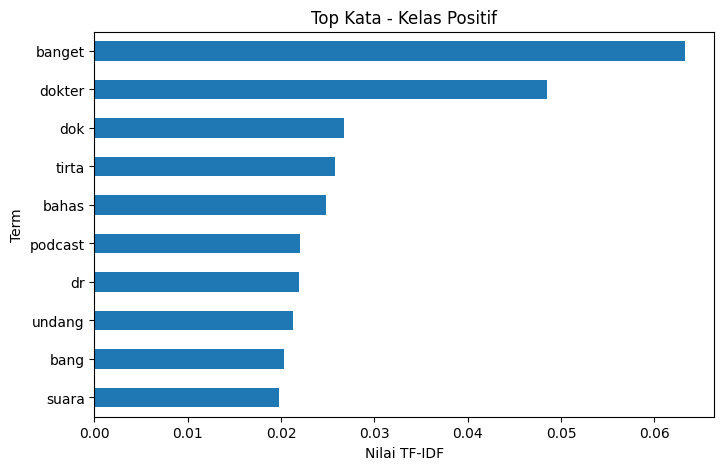

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

tfidf_features_for_plotting_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=feature_names
)

tfidf_features_for_plotting_df['sentiment'] = y_train.reset_index(drop=True)

mean_tfidf = tfidf_features_for_plotting_df.groupby('sentiment').mean()

for label in mean_tfidf.index:
    top_terms = mean_tfidf.loc[label].sort_values(ascending=False).head(10)

    plt.figure(figsize=(8,5))
    top_terms.sort_values().plot(kind='barh')  # horizontal bar
    plt.title(f"Top Kata - Kelas {label}")
    plt.xlabel("Nilai TF-IDF")
    plt.ylabel("Term")
    plt.show()

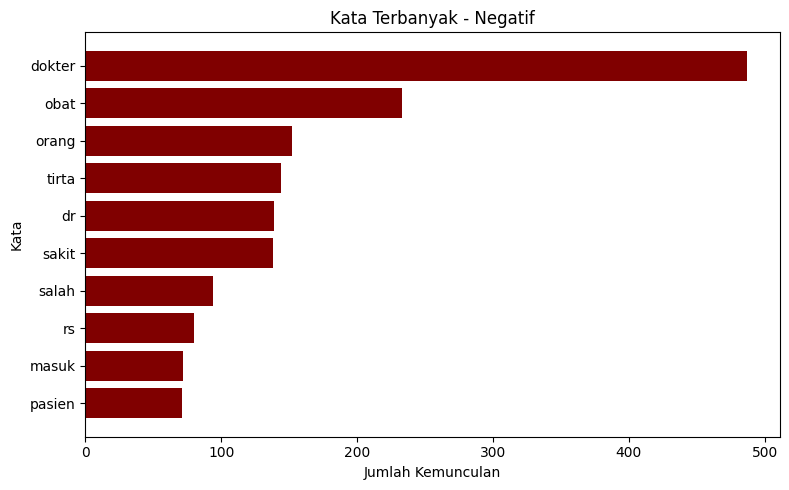

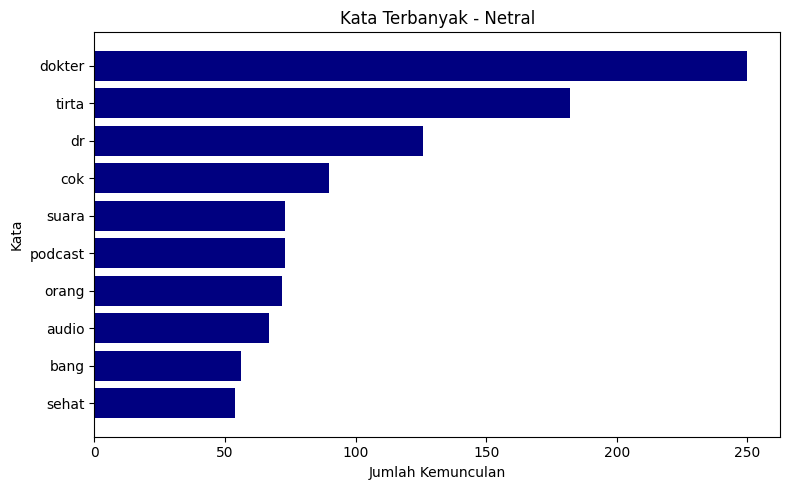

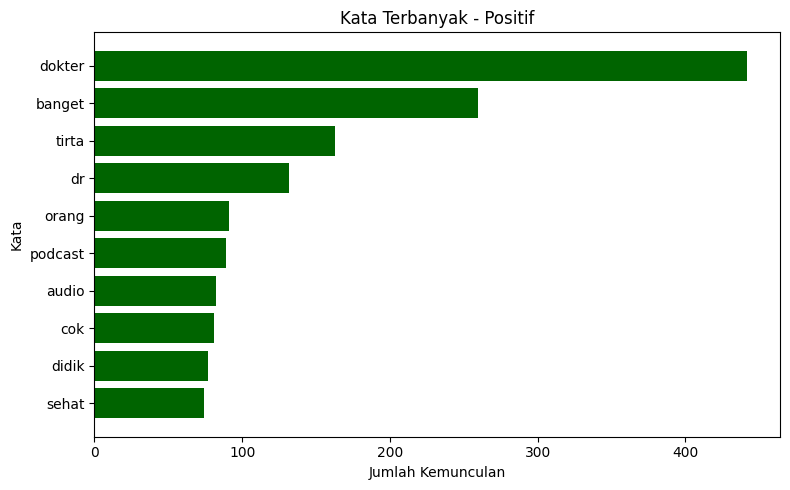

In [20]:
from collections import Counter
import matplotlib.pyplot as plt

# Define a list of colors for each sentiment class
colors = {'Negatif': 'maroon', 'Netral': 'navy', 'Positif': 'darkgreen'}

for label in komentar_df['label'].unique():
    # Gunakan 'final_text' yang sudah diproses
    text_data = komentar_df[komentar_df['label'] == label]['final_text']

    # Gabungkan semua teks menjadi satu string dan split menjadi kata-kata
    all_words = ' '.join(text_data).split()
    word_counts = Counter(all_words)

    # Ambil 10 kata teratas
    top_words = dict(word_counts.most_common(10))

    # Buat plot
    plt.figure(figsize=(8,5))
    # Urutkan secara menaik agar yang terbanyak di atas
    sorted_words = sorted(top_words.items(), key=lambda x: x[1])

    # Gunakan warna yang sesuai dengan label sentimen
    color = colors.get(label, 'grey') # Default to grey if label not in colors map
    plt.barh([word for word, count in sorted_words], [count for word, count in sorted_words], color=color)

    plt.title(f"Kata Terbanyak - {label}")
    plt.xlabel("Jumlah Kemunculan")
    plt.ylabel("Kata")
    plt.tight_layout()
    plt.show()

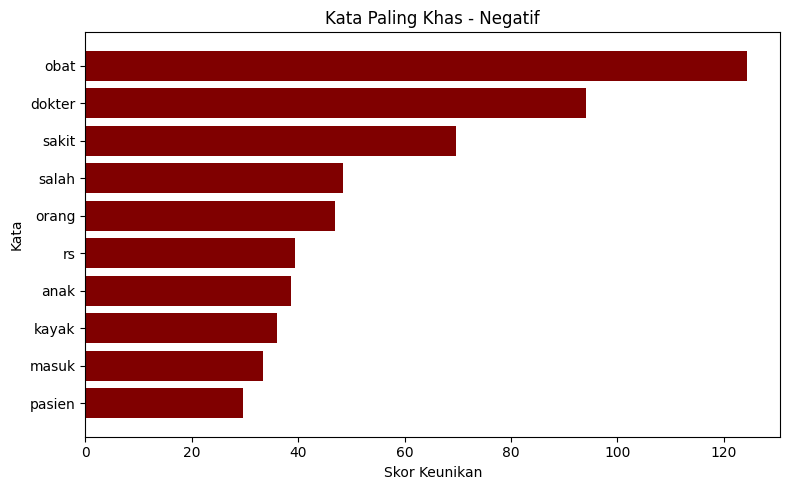

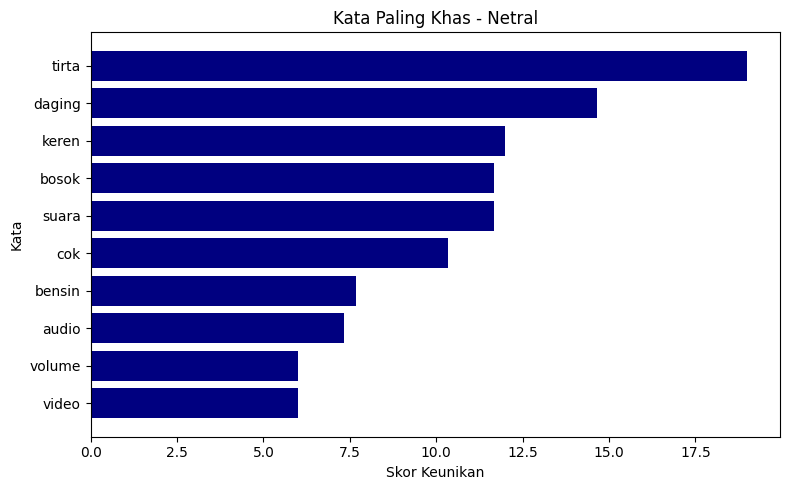

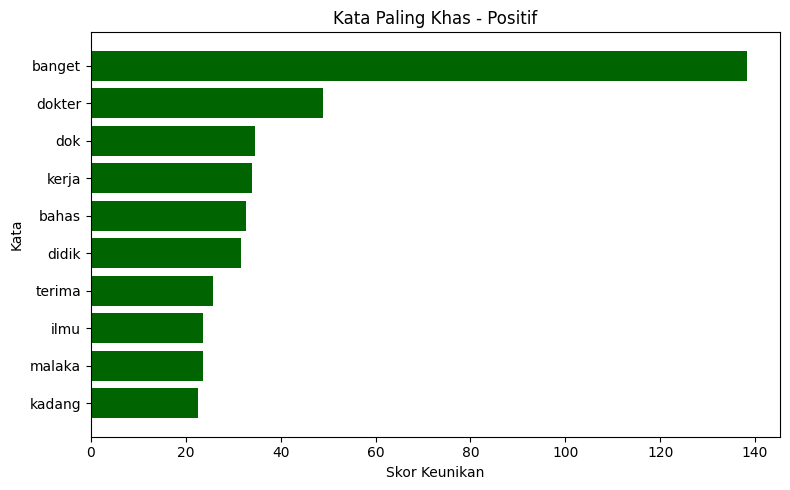

In [21]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Define colors
colors = {'Negatif': 'maroon', 'Netral': 'navy', 'Positif': 'darkgreen'}

# ===============================
# 1. Hitung frekuensi kata per kelas
# ===============================
class_word_counts = {}

for label in komentar_df['label'].unique():
    text_data = komentar_df[komentar_df['label'] == label]['final_text']
    all_words = ' '.join(text_data).split()
    class_word_counts[label] = Counter(all_words)

# ===============================
# 2. Ubah ke DataFrame
# ===============================
df_counts = pd.DataFrame(class_word_counts).fillna(0)

# ===============================
# 3. Hitung "keunikan" (diff)
# ===============================
# nilai tiap kelas dikurangi rata-rata semua kelas
df_diff = df_counts.sub(df_counts.mean(axis=1), axis=0)

# ===============================
# 4. Plot per kelas
# ===============================
for label in df_diff.columns:
    # ambil top 10 kata paling khas
    top_words = df_diff[label].sort_values(ascending=False).head(10)

    plt.figure(figsize=(8,5))

    # urutkan biar enak dibaca (yang besar di atas)
    sorted_words = top_words.sort_values()

    color = colors.get(label, 'grey')

    plt.barh(sorted_words.index, sorted_words.values, color=color)
    plt.title(f"Kata Paling Khas - {label}")
    plt.xlabel("Skor Keunikan")
    plt.ylabel("Kata")
    plt.tight_layout()
    plt.show()

## Data Training

In [22]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

# ================================================================
# TRAINING MODEL SVM MULTICLASS (OAA)
# ================================================================
print("\n--- Memulai Pelatihan Model SVM ---")

kernels = ['linear', 'poly', 'rbf']
svm_models = {}

for k in kernels:

    print(f"\nMelatih SVM Kernel {k.upper()}...")

    model = OneVsRestClassifier(
        SVC(
            kernel=k,
            probability=True,
            random_state=42
        )
    )

    # TRAINING MODEL
    model.fit(X_train_tfidf, y_train)

    svm_models[k] = model

    print(f"✅ Training kernel {k.upper()} selesai")

print("\n✅ Semua model selesai dilatih.")


--- Memulai Pelatihan Model SVM ---

Melatih SVM Kernel LINEAR...
✅ Training kernel LINEAR selesai

Melatih SVM Kernel POLY...
✅ Training kernel POLY selesai

Melatih SVM Kernel RBF...
✅ Training kernel RBF selesai

✅ Semua model selesai dilatih.


## Evaluasi Model

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("\n--- Memulai Evaluasi Model pada Data Uji ---")

# List untuk menampung ringkasan hasil agar bisa dibuat tabel
summary_results = []

# Kita looping isi dictionary svm_models yang sudah dilatih tadi
for kernel_name, model in svm_models.items():
    print(f"\n[ Mengevaluasi Kernel: {kernel_name.upper()} ]")

    # 1. Prediksi data uji
    y_pred = model.predict(X_test_tfidf)

    # 2. Hitung Metrik secara rinci
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # 3. Simpan hasil ke ringkasan
    summary_results.append({
        'Kernel': kernel_name.upper(),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # 4. Tampilkan Classification Report per kernel (untuk lampiran skripsi)
    print(f"Classification Report {kernel_name.upper()}:")
    # Pastikan target_names sesuai dengan urutan label lo (misal: Negatif, Netral, Positif)
    print(classification_report(y_test, y_pred))

# =================================================================
# TAMPILKAN TABEL KOMPARASI AKHIR
# =================================================================
print("\n--- TABEL PERBANDINGAN PERFORMA KERNEL ---")

df_komparasi = pd.DataFrame(summary_results)

# Mengurutkan berdasarkan akurasi tertinggi
df_komparasi = df_komparasi.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print(df_komparasi)


# =================================================================
# MENENTUKAN KERNEL TERBAIK
# =================================================================
best_kernel = df_komparasi.iloc[0]['Kernel']
best_accuracy = df_komparasi.iloc[0]['Accuracy']

print("\n===================================================")
print(f"✅ Kernel Terbaik           : {best_kernel.upper()}")
print(f"✅ Akurasi Tertinggi        : {best_accuracy:.4f}")
print("===================================================")



--- Memulai Evaluasi Model pada Data Uji ---

[ Mengevaluasi Kernel: LINEAR ]
Classification Report LINEAR:
              precision    recall  f1-score   support

     Negatif       0.75      0.59      0.66       187
      Netral       0.67      0.83      0.75       276
     Positif       0.82      0.72      0.77       203

    accuracy                           0.73       666
   macro avg       0.75      0.72      0.73       666
weighted avg       0.74      0.73      0.73       666


[ Mengevaluasi Kernel: POLY ]
Classification Report POLY:
              precision    recall  f1-score   support

     Negatif       0.73      0.37      0.49       187
      Netral       0.53      0.86      0.66       276
     Positif       0.75      0.47      0.58       203

    accuracy                           0.60       666
   macro avg       0.67      0.57      0.58       666
weighted avg       0.65      0.60      0.59       666


[ Mengevaluasi Kernel: RBF ]
Classification Report RBF:
             

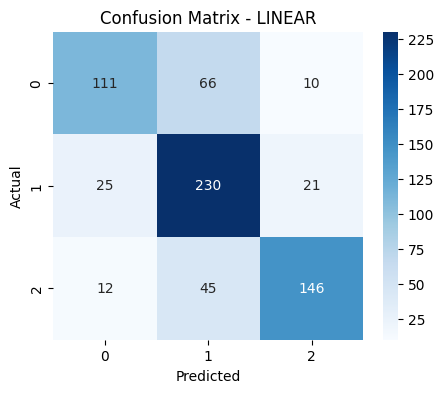

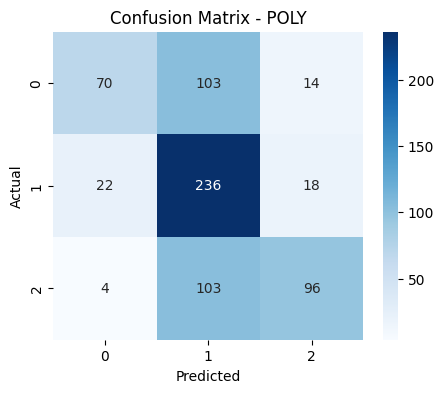

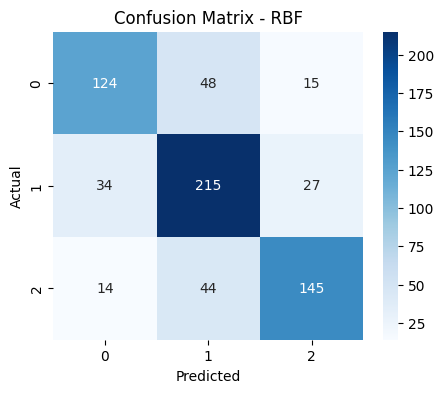

In [24]:
for kernel_name, model in svm_models.items():

    y_pred = model.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {kernel_name.upper()}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# Algoritma Perhitungan Manual

## Pisahkan Fitur dan Label

In [25]:
import pandas as pd

# Dataset contoh perhitungan manual
data_manual = {
    'X1': [4,5,1,2,2,3],
    'X2': [1,2,5,4,2,3],
    'kelas': [
        'Positif',
        'Positif',
        'Negatif',
        'Negatif',
        'Netral',
        'Netral'
    ]
}

df_manual = pd.DataFrame(data_manual)

print(df_manual)

   X1  X2    kelas
0   4   1  Positif
1   5   2  Positif
2   1   5  Negatif
3   2   4  Negatif
4   2   2   Netral
5   3   3   Netral


In [26]:
X_manual = df_manual[['X1','X2']]
y_manual = df_manual['kelas']

## Encode Label

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_manual)

print("\nMapping Label:")
for i, label in enumerate(le.classes_):
    print(label, "=", i)


Mapping Label:
Negatif = 0
Netral = 1
Positif = 2


## Training Model SVM

In [28]:
print("\n--- Training SVM Manual Dataset ---")

svm_manual = OneVsRestClassifier(
    SVC(kernel='linear')
)

svm_manual.fit(X_manual, y_encoded)

print("✅ Training selesai")


--- Training SVM Manual Dataset ---
✅ Training selesai


## Cek Hasil Prediksi Data Train

In [29]:
y_pred_train = svm_manual.predict(X_manual)

df_manual['Prediksi_Model'] = \
    le.inverse_transform(y_pred_train)

print("\n=== Hasil Prediksi Data Latih ===")
print(df_manual)


=== Hasil Prediksi Data Latih ===
   X1  X2    kelas Prediksi_Model
0   4   1  Positif        Positif
1   5   2  Positif        Positif
2   1   5  Negatif        Negatif
3   2   4  Negatif        Negatif
4   2   2   Netral         Netral
5   3   3   Netral        Positif


## Data Uji Baru

In [30]:
data_uji = pd.DataFrame([[3,2]],columns=['X1','X2'])

print("\nData uji:", data_uji)


Data uji:    X1  X2
0   3   2


## Prediksi Data Uji

In [31]:
prediksi = svm_manual.predict(data_uji)

hasil_kelas = le.inverse_transform(prediksi)

print(f"Data uji {data_uji.iloc[0].to_dict()} diklasifikasikan sebagai:")
print(f"✅ {hasil_kelas[0]}")

Data uji {'X1': 3, 'X2': 2} diklasifikasikan sebagai:
✅ Positif


# Implementasi Prediksi Model SVM

In [33]:
# =========================================================
# PIPELINE PREPROCESSING
# =========================================================

def preprocess_text(text):

    # 1. Cleaning
    text = cleaning(text)

    # 2. Case Folding
    text = case_folding(text)

    # 3. Tokenizing
    tokens = word_tokenize(text)

    # 4. Normalization
    tokens = normalize_text(tokens)

    # 5. Stopword Removal
    tokens = filtering(tokens, list_stopwords)

    # 6. Stemming
    tokens = stemming(tokens)

    # 7. Join kembali menjadi kalimat
    final_text = ' '.join(tokens)

    return final_text


# =========================================
# IMPLEMENTASI PREDIKSI SENTIMEN
# =========================================

# 5 contoh kalimat baru
kalimat_baru = [
    "Terima kasih udah bikin konten ini bang",
    "Pantesan sekarang banyak pasien di rumah sakit nggak tahu mereka sakit apa!",
    "Podcast paling keren yang pernah gue lihat",
    "biasa aja si menurut gue, no offense",
    "dipotong mulu jadi kesel nontonnya"

]

# Preprocessing teks
kalimat_preprocessed = [preprocess_text(text) for text in kalimat_baru]

# Transformasi TF-IDF
kalimat_tfidf = tfidf.transform(kalimat_preprocessed)

# Prediksi sentimen menggunakan model terbaik
hasil_prediksi = svm_models['linear'].predict(kalimat_tfidf)

# Menampilkan hasil prediksi
for teks, prediksi in zip(kalimat_baru, hasil_prediksi):
    print(f"Kalimat              : {teks}")
    print(f"Prediksi Sentimen    : {prediksi}")
    print("-" * 60)


Kalimat              : Terima kasih udah bikin konten ini bang
Prediksi Sentimen    : Positif
------------------------------------------------------------
Kalimat              : Pantesan sekarang banyak pasien di rumah sakit nggak tahu mereka sakit apa!
Prediksi Sentimen    : Negatif
------------------------------------------------------------
Kalimat              : Podcast paling keren yang pernah gue lihat
Prediksi Sentimen    : Positif
------------------------------------------------------------
Kalimat              : biasa aja si menurut gue, no offense
Prediksi Sentimen    : Netral
------------------------------------------------------------
Kalimat              : dipotong mulu jadi kesel nontonnya
Prediksi Sentimen    : Negatif
------------------------------------------------------------
